# Feature Engineering & Data Preprocessing

**Objectives:**
1. Handle missing values.
2. Remove low-value features.
3. Fix data quality issues.
4. Create business-driven features.
5. Encode categorical variables.
6. Prepare model-ready dataset.
7. Save processed data for modeling.


### Section 2: Import Libraries


In [1]:
import pandas as pd
import numpy as np
from sklearn.impute import SimpleImputer

pd.set_option("display.max_columns", None)


### Section 3: Load Dataset


In [2]:
df = pd.read_csv("../data/raw/application_train.csv")
print(df.shape)
# Expected: (307511, 122)


(307511, 122)


### Section 4: Missing Value Analysis


In [3]:
missing_pct = (
    df.isnull()
      .mean()
      * 100
).sort_values(ascending=False)

missing_pct.head(20)


COMMONAREA_AVG              69.872297
COMMONAREA_MODE             69.872297
COMMONAREA_MEDI             69.872297
NONLIVINGAPARTMENTS_MEDI    69.432963
NONLIVINGAPARTMENTS_MODE    69.432963
NONLIVINGAPARTMENTS_AVG     69.432963
FONDKAPREMONT_MODE          68.386172
LIVINGAPARTMENTS_AVG        68.354953
LIVINGAPARTMENTS_MEDI       68.354953
LIVINGAPARTMENTS_MODE       68.354953
FLOORSMIN_MODE              67.848630
FLOORSMIN_AVG               67.848630
FLOORSMIN_MEDI              67.848630
YEARS_BUILD_AVG             66.497784
YEARS_BUILD_MODE            66.497784
YEARS_BUILD_MEDI            66.497784
OWN_CAR_AGE                 65.990810
LANDAREA_MEDI               59.376738
LANDAREA_AVG                59.376738
LANDAREA_MODE               59.376738
dtype: float64

### Section 5: Remove High Missing Columns

**Business Note:** Columns with more than 60% missing values are removed because they provide limited reliable information and increase preprocessing complexity.


In [4]:
THRESHOLD = 60

high_missing_cols = missing_pct[
    missing_pct > THRESHOLD
].index.tolist()

print(f"Number of columns with > {THRESHOLD}% missing values: {len(high_missing_cols)}")


Number of columns with > 60% missing values: 17


In [5]:
df = df.drop(columns=high_missing_cols)
print(df.shape)


(307511, 105)


### Section 6: Handle Special Values
Home Credit contains an abnormal value in `DAYS_EMPLOYED` representing an unrealistic duration (365243). We will replace this with `NaN`.


In [6]:
df["DAYS_EMPLOYED"].value_counts().head()


DAYS_EMPLOYED
 365243    55374
-200         156
-224         152
-230         151
-199         151
Name: count, dtype: int64

In [7]:
df["DAYS_EMPLOYED"] = df["DAYS_EMPLOYED"].replace(365243, np.nan)


In [8]:
df["DAYS_EMPLOYED"].describe()


count    252137.000000
mean      -2384.169325
std        2338.360162
min      -17912.000000
25%       -3175.000000
50%       -1648.000000
75%        -767.000000
max           0.000000
Name: DAYS_EMPLOYED, dtype: float64

### Section 7: Missing Value Imputation


In [9]:
num_cols = df.select_dtypes(exclude="object").columns
cat_cols = df.select_dtypes(include="object").columns


**Numerical Features: Median Imputation**


In [10]:
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())


**Categorical Features: Mode Imputation**


In [11]:
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])


**Validation:** Check if any missing values remain.


In [12]:
df.isnull().sum().sum()
# Expected: 0


np.int64(0)

### Section 8: Outlier Analysis


In [13]:
important_features = [
    "AMT_INCOME_TOTAL",
    "AMT_CREDIT",
    "AMT_ANNUITY"
]

df[important_features].describe().T


,count,mean,std,min,25%,50%,75%,max
AMT_INCOME_TOTAL,307511.0,168797.919297,237123.146279,25650.0,112500.0,147150.0,202500.0,117000000.0
AMT_CREDIT,307511.0,599025.999706,402490.776996,45000.0,270000.0,513531.0,808650.0,4050000.0
AMT_ANNUITY,307511.0,27108.487841,14493.461065,1615.5,16524.0,24903.0,34596.0,258025.5


### Section 9: Outlier Treatment
Using percentile capping (1st and 99th percentiles).


In [14]:
for col in important_features:
    lower = df[col].quantile(0.01)
    upper = df[col].quantile(0.99)
    df[col] = np.clip(df[col], lower, upper)


In [15]:
df[important_features].describe().T


,count,mean,std,min,25%,50%,75%,max
AMT_INCOME_TOTAL,307511.0,166067.479607,83000.171936,45000.0,112500.0,147150.0,202500.0,472500.0
AMT_CREDIT,307511.0,596305.992938,391307.539391,76410.0,270000.0,513531.0,808650.0,1854000.0
AMT_ANNUITY,307511.0,26945.208570,13654.548817,6183.0,16524.0,24903.0,34596.0,70006.5


### Section 10: Business Feature Engineering
Create features frequently used in credit-risk modeling.


**Feature 1: Credit-to-Income Ratio**
*Interpretation:* Higher ratio may indicate greater financial burden.


In [16]:
df["CREDIT_INCOME_RATIO"] = df["AMT_CREDIT"] / df["AMT_INCOME_TOTAL"]


C:\Users\VINAYAK\AppData\Local\Temp\ipykernel_15440\2016561784.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["CREDIT_INCOME_RATIO"] = df["AMT_CREDIT"] / df["AMT_INCOME_TOTAL"]


**Feature 2: Annuity-to-Income Ratio**
*Interpretation:* Represents installment burden relative to income.


In [17]:
df["ANNUITY_INCOME_RATIO"] = df["AMT_ANNUITY"] / df["AMT_INCOME_TOTAL"]


C:\Users\VINAYAK\AppData\Local\Temp\ipykernel_15440\4292850134.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["ANNUITY_INCOME_RATIO"] = df["AMT_ANNUITY"] / df["AMT_INCOME_TOTAL"]


**Feature 3: Goods-to-Credit Ratio**


In [18]:
df["GOODS_CREDIT_RATIO"] = df["AMT_GOODS_PRICE"] / df["AMT_CREDIT"]


C:\Users\VINAYAK\AppData\Local\Temp\ipykernel_15440\1524067986.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["GOODS_CREDIT_RATIO"] = df["AMT_GOODS_PRICE"] / df["AMT_CREDIT"]


**Feature 4: Employment-to-Age Ratio**


In [19]:
df["EMPLOYMENT_AGE_RATIO"] = df["DAYS_EMPLOYED"] / df["DAYS_BIRTH"]


C:\Users\VINAYAK\AppData\Local\Temp\ipykernel_15440\753896276.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["EMPLOYMENT_AGE_RATIO"] = df["DAYS_EMPLOYED"] / df["DAYS_BIRTH"]


**Feature 5: Income per Family Member**


In [20]:
df["INCOME_PER_FAMILY_MEMBER"] = df["AMT_INCOME_TOTAL"] / df["CNT_FAM_MEMBERS"]


C:\Users\VINAYAK\AppData\Local\Temp\ipykernel_15440\2391215417.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["INCOME_PER_FAMILY_MEMBER"] = df["AMT_INCOME_TOTAL"] / df["CNT_FAM_MEMBERS"]


### Section 11: Feature Validation


In [21]:
new_features = [
    "CREDIT_INCOME_RATIO",
    "ANNUITY_INCOME_RATIO",
    "GOODS_CREDIT_RATIO",
    "EMPLOYMENT_AGE_RATIO",
    "INCOME_PER_FAMILY_MEMBER"
]

df[new_features].describe().T


,count,mean,std,min,25%,50%,75%,max
CREDIT_INCOME_RATIO,307511.0,3.947609,2.641730,0.161714,2.026933,3.271525,5.142857,41.200000
ANNUITY_INCOME_RATIO,307511.0,0.180426,0.092330,0.013086,0.115385,0.162473,0.227800,1.555700
GOODS_CREDIT_RATIO,307511.0,0.901290,0.108863,0.166667,0.834725,0.893815,1.000000,6.666667
EMPLOYMENT_AGE_RATIO,307511.0,0.142371,0.124883,-0.000000,0.066852,0.091037,0.191054,0.728811
INCOME_PER_FAMILY_MEMBER,307511.0,91752.002227,63110.423904,2812.500000,47250.000000,75000.000000,112500.000000,472500.000000


### Section 12: Encode Categorical Variables
One-Hot Encoding:


In [22]:
df = pd.get_dummies(df, drop_first=True)
print(df.shape)
# Observation: Feature count should increase significantly.


(307511, 216)


### Section 13: Feature Correlation Review


In [23]:
corr_target = (
    df.corr(numeric_only=True)["TARGET"]
      .abs()
      .sort_values(ascending=False)
)

corr_target.head(20)


TARGET                                               1.000000
EXT_SOURCE_2                                         0.160295
EXT_SOURCE_3                                         0.155892
EXT_SOURCE_1                                         0.098887
DAYS_BIRTH                                           0.078239
DAYS_EMPLOYED                                        0.063368
REGION_RATING_CLIENT_W_CITY                          0.060893
REGION_RATING_CLIENT                                 0.058899
GOODS_CREDIT_RATIO                                   0.057919
NAME_INCOME_TYPE_Working                             0.057481
NAME_EDUCATION_TYPE_Higher education                 0.056593
DAYS_LAST_PHONE_CHANGE                               0.055218
CODE_GENDER_M                                        0.054713
DAYS_ID_PUBLISH                                      0.051457
REG_CITY_NOT_WORK_CITY                               0.050994
NAME_EDUCATION_TYPE_Secondary / secondary special    0.049824
EMPLOYME

**Visualize Top Predictive Features**


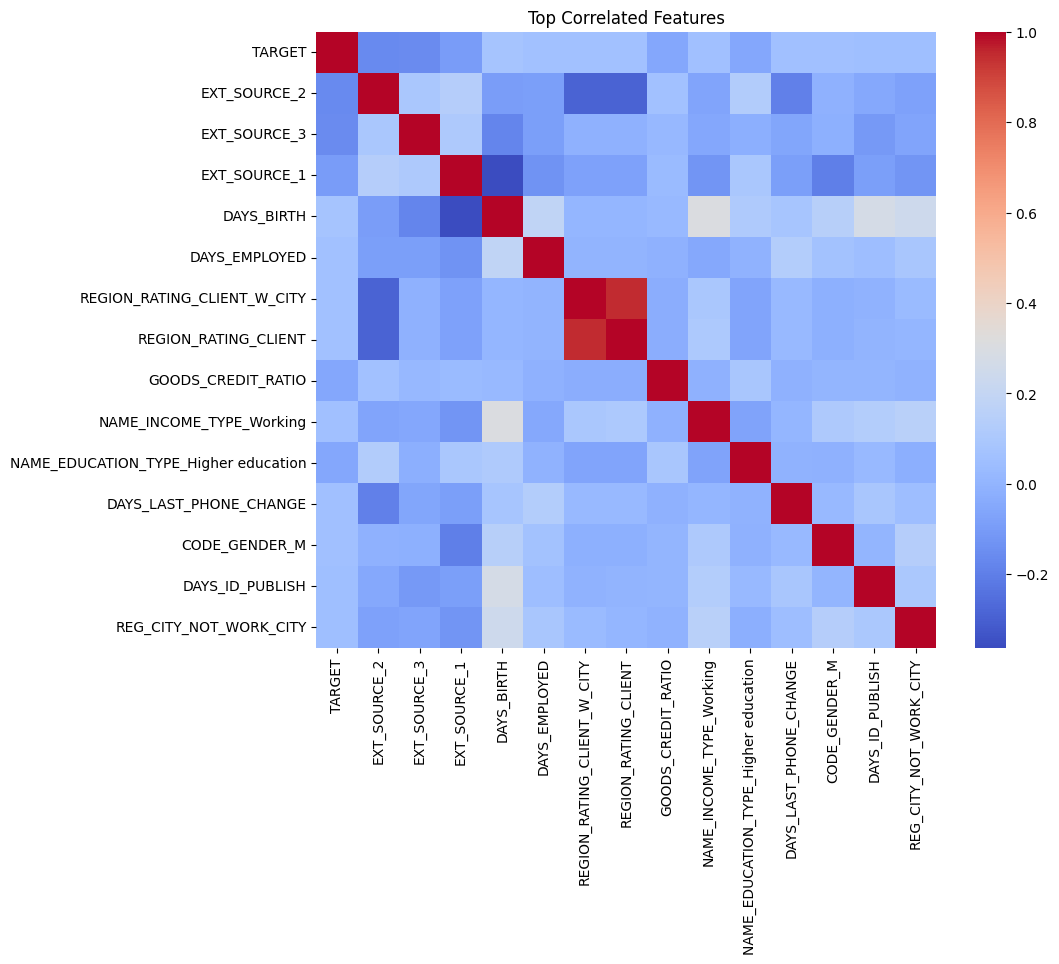

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

top_features = corr_target.head(15).index

plt.figure(figsize=(10, 8))
sns.heatmap(
    df[top_features].corr(),
    annot=False,
    cmap="coolwarm"
)
plt.title("Top Correlated Features")
plt.show()


### Section 14: Create Modeling Dataset


In [25]:
X = df.drop(columns=["TARGET"])
y = df["TARGET"]

print(X.shape)
print(y.shape)


(307511, 215)
(307511,)


### Section 15: Save Processed Dataset


In [26]:
processed_df = pd.concat([X, y], axis=1)
processed_df.to_csv("../data/processed/model_data.csv", index=False)


In [27]:
processed_df.head()


,SK_ID_CURR,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,LANDAREA_AVG,LIVINGAREA_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,LANDAREA_MODE,LIVINGAREA_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,LANDAREA_MEDI,LIVINGAREA_MEDI,NONLIVINGAREA_MEDI,TOTALAREA_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,CREDIT_INCOME_RATIO,ANNUITY_INCOME_RATIO,GOODS_CREDIT_RATIO,EMPLOYMENT_AGE_RATIO,INCOME_PER_FAMILY_MEMBER,NAME_CONTRACT_TYPE_Revolving loans,CODE_GENDER_M,CODE_GENDER_XNA,FLAG_OWN_CAR_Y,FLAG_OWN_REALTY_Y,NAME_TYPE_SUITE_Family,NAME_TYPE_SUITE_Group of people,NAME_TYPE_SUITE_Other_A,NAME_TYPE_SUITE_Other_B,"NAME_TYPE_SUITE_Spouse, partner",NAME_TYPE_SUITE_Unaccompanied,NAME_INCOME_TYPE_Commercial associate,NAME_INCOME_TYPE_Maternity leave,NAME_INCOME_TYPE_Pensioner,NAME_INCOME_TYPE_State servant,NAME_INCOME_TYPE_Student,NAME_INCOME_TYPE_Unemployed,NAME_INCOME_TYPE_Working,NAME_EDUCATION_TYPE_Higher education,NAME_EDUCATION_TYPE_Incomplete higher,NAME_EDUCATION_TYPE_Lower secondary,NAME_EDUCATION_TYPE_Secondary / secondary special,NAME_FAMILY_STATUS_Married,NAME_FAMILY_STATUS_Separated,NAME_FAMILY_STATUS_Single / not married,NAME_FAMILY_STATUS_Unknown,NAME_FAMILY_STATUS_Widow,NAME_HOUSING_TYPE_House / apartment,NAME_HOUSING_TYPE_Municipal apartment,NAME_HOUSING_TYPE_Office apartment,NAME_HOUSING_TYPE_Rented apartment,NAME_HOUSING_TYPE_With parents,OCCUPATION_TYPE_Cleaning staff,OCCUPATION_TYPE_Cooking staff,OCCUPATION_TYPE_Core staff,OCCUPATION_TYPE_Drivers,OCCUPATION_TYPE_HR staff,OCCUPATION_TYPE_High skill tech staff,OCCUPATION_TYPE_IT staff,OCCUPATION_TYPE_Laborers,OCCUPATION_TYPE_Low-skill Laborers,OCCUPATION_TYPE_Managers,OCCUPATION_TYPE_Medicine staff,OCCUPATION_TYPE_Private service staff,OCCUPATION_TYPE_Realty agents,OCCUPATION_TYPE_Sales staff,OCCUPATION_TYPE_Secretaries,OCCUPATION_TYPE_Security staff,OCCUPATION_TYPE_Waiters/barmen staff,WEEKDAY_APPR_PROCESS_START_MONDAY,WEEKDAY_APPR_PROCESS_START_SATURDAY,WEEKDAY_APPR_PROCESS_START_SUNDAY,WEEKDAY_APPR_PROCESS_START_THURSDAY,WEEKDAY_APPR_PROCESS_START_TUESDAY,WEEKDAY_APPR_PROCESS_START_WEDNESDAY,ORGANIZATION_TYPE_Agriculture,ORGANIZATION_TYPE_Bank,ORGANIZATION_TYPE_Business Entity Type 1,ORGANIZATION_TYPE_Business Entity Type 2,ORGANIZATION_TYPE_Business Entity Type 3,ORGANIZATION_TYPE_Cleaning,ORGANIZATION_TYPE_Construction,ORGANIZATION_TYPE_Culture,ORGANIZATION_TYPE_Electricity,ORGANIZATION_TYPE_Emergency,ORGANIZATION_TYPE_Government,ORGANIZATION_TYPE_Hotel,ORGANIZATION_TYPE_Housing,ORGANIZATION_TYPE_Industry: type 1,ORGANIZATION_TYPE_Industry: type 10,ORGANIZATION_TYPE_Industry: type 11,ORGANIZATION_TYPE_Industry: type 12,ORGANIZATION_TYPE_Industry: type 13,ORGANIZATION_TYPE_Indus

## Key Findings

1. Missing values were handled successfully.
2. High-missing features were removed.
3. Data quality issues were corrected.
4. New business features were engineered.
5. Categorical variables were encoded.
6. A model-ready dataset was created.

### Deliverables
* ✓ Missing values handled
* ✓ High-missing columns removed
* ✓ Outliers treated
* ✓ Business features engineered
* ✓ Categorical variables encoded
* ✓ Model-ready dataset generated
* ✓ Processed file saved

**Output File:** `data/processed/model_data.csv`

This dataset will be used in Notebook 4 for Logistic Regression baseline modeling.
